# Exploratory Data Analysis (EDA) on Superstore Dataset

## Project Objective

The objective of this project is to analyze sales data, identify business trends, evaluate profitability, and generate actionable insights using Exploratory Data Analysis (EDA) techniques.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
plt.style.use('dark_background')

PRIMARY = '#00E5FF'
SECONDARY = '#7C4DFF'
ACCENT = '#00E676'
WARNING = '#FF9100'
DANGER = '#FF5252'  

In [2]:
df = pd.read_csv("Sample-Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

## Dataset Overview

This section explores the structure of the dataset, including the number of records, available features, and data types.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

## Statistical Summary

Descriptive statistics are used to understand the distribution and characteristics of numerical variables.

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### Dataset Dimensions

The dataset contains rows and columns representing transactional records and business attributes used for analysis.

In [6]:
df.shape

(9994, 21)

In [7]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

## Key Performance Indicators (KPIs)

This section provides a quick overview of the company's overall business performance.

### Objective
To summarize the most important business metrics in a single view.

### Metrics Included
- Total Sales
- Total Profit
- Total Orders
- Average Discount

### Insight
These KPIs provide a high-level understanding of the company's financial performance and operational scale.

In [9]:
print("Total Sales: ", round(df['Sales'].sum(),2))
print("Total Profit: ", round(df['Profit'].sum(),2))
print("Total Orders: ", df['Order ID'].nunique())
print("Average Discount: ", round(df['Discount'].mean()*100,2), "%")

Total Sales:  2297200.86
Total Profit:  286397.02
Total Orders:  5009
Average Discount:  15.62 %


## Sales by Category Analysis

This visualization compares the total sales generated by each product category.

### Objective
To identify which category contributes the highest revenue to the business.

### Observation
Technology generated the highest sales, followed by Furniture and Office Supplies.

### Insight
Technology products are the primary revenue drivers and play a significant role in overall business performance.

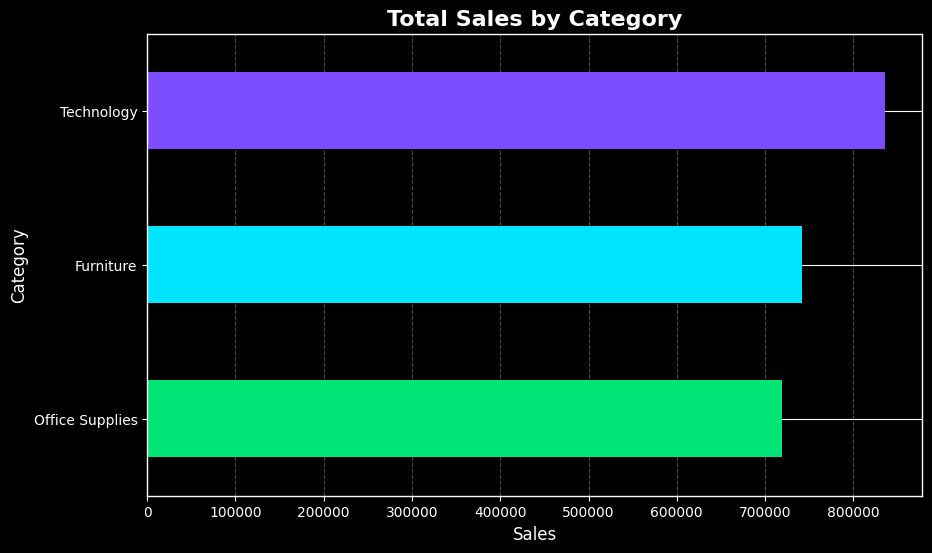

In [10]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values()

plt.figure(figsize=(10,6))

category_sales.plot(
    kind='barh',
    color=['#00E676','#00E5FF','#7C4DFF']
)

plt.title('Total Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Sales')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

## Profit by Category Analysis

This visualization shows the total profit earned from each product category.

### Objective
To determine which category contributes the most profit.

### Observation
Technology generated the highest profit, while Furniture produced the lowest profit despite having strong sales.

### Insight
Furniture may have lower profit margins due to higher discounts, operational costs, or shipping expenses.

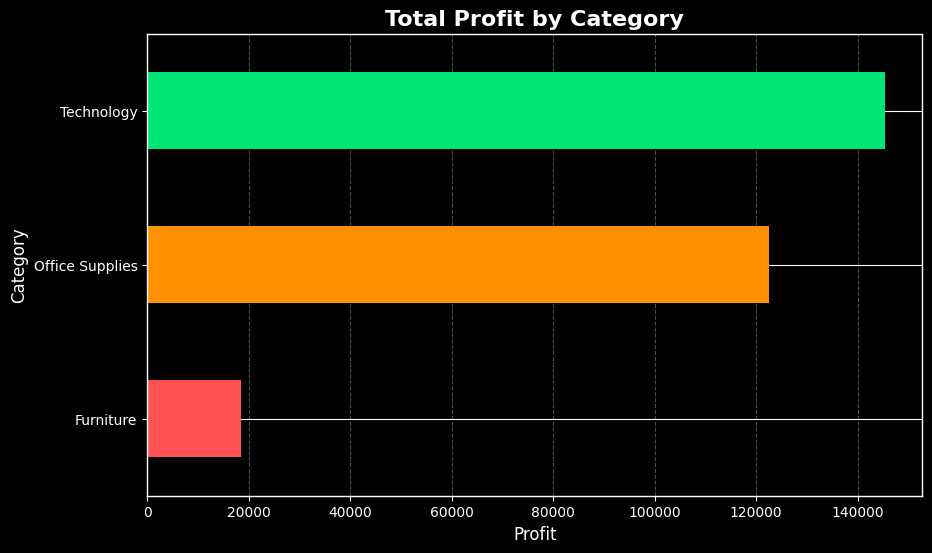

In [11]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values()

plt.figure(figsize=(10,6))

category_profit.plot(
    kind='barh',
    color=['#FF5252','#FF9100','#00E676']
)

plt.title('Total Profit by Category', fontsize=16, fontweight='bold')
plt.xlabel('Profit')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

## Regional Sales Analysis

This chart compares total sales across different regions.

### Objective
To identify the best-performing sales region.

### Observation
The West region recorded the highest sales, while the South region generated the lowest sales.

### Insight
The West region is a major contributor to company revenue and represents a strong market for business growth.

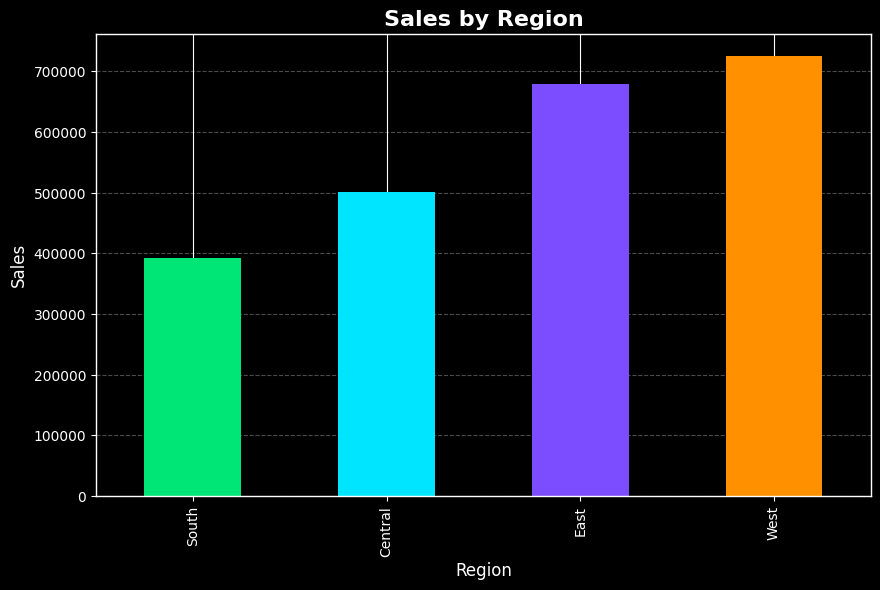

In [12]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values()

plt.figure(figsize=(10,6))

region_sales.plot(
    kind='bar',
    color=['#00E676','#00E5FF','#7C4DFF','#FF9100']
)

plt.title('Sales by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

## Regional Profit Analysis

This visualization compares profitability across different regions.

### Objective
To determine which region contributes the most profit.

### Observation
The West region generated the highest profit, while the Central region showed the lowest profitability.

### Insight
The company should investigate factors affecting profitability in lower-performing regions and replicate successful strategies from the West region.

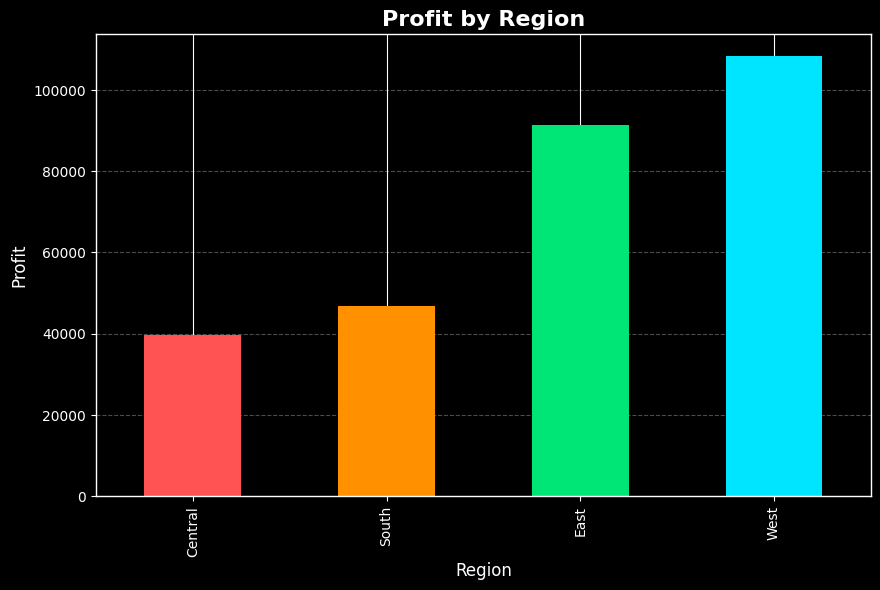

In [13]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values()

plt.figure(figsize=(10,6))

region_profit.plot(
    kind='bar',
    color=['#FF5252','#FF9100','#00E676','#00E5FF']
)

plt.title('Profit by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month

## Monthly Sales Trend Analysis

This line chart illustrates how sales vary throughout the year.

### Objective
To identify seasonal patterns and peak sales periods.

### Observation
Sales remained relatively stable during the middle months and increased significantly during the final quarter of the year.

### Insight
November and December recorded the highest sales, indicating strong seasonal demand during year-end periods.

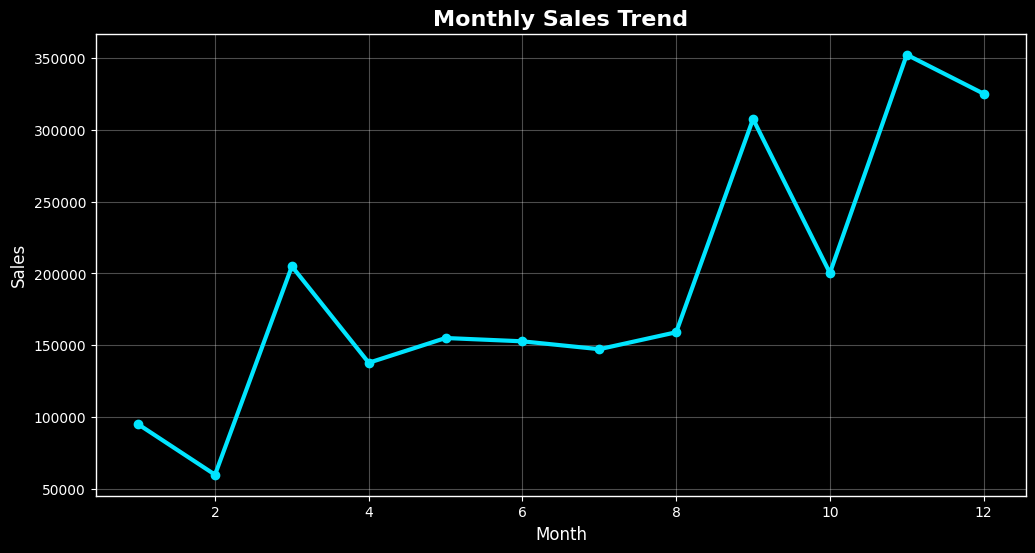

In [15]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=3,
    color='#00E5FF'
)

plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)

plt.show()

## Top 10 Products Analysis

This visualization highlights the products generating the highest sales revenue.

### Objective
To identify the most valuable products in the inventory.

### Observation
A small number of products contribute a significant portion of total sales.

### Insight
These products should receive priority in inventory management, marketing campaigns, and promotional activities.

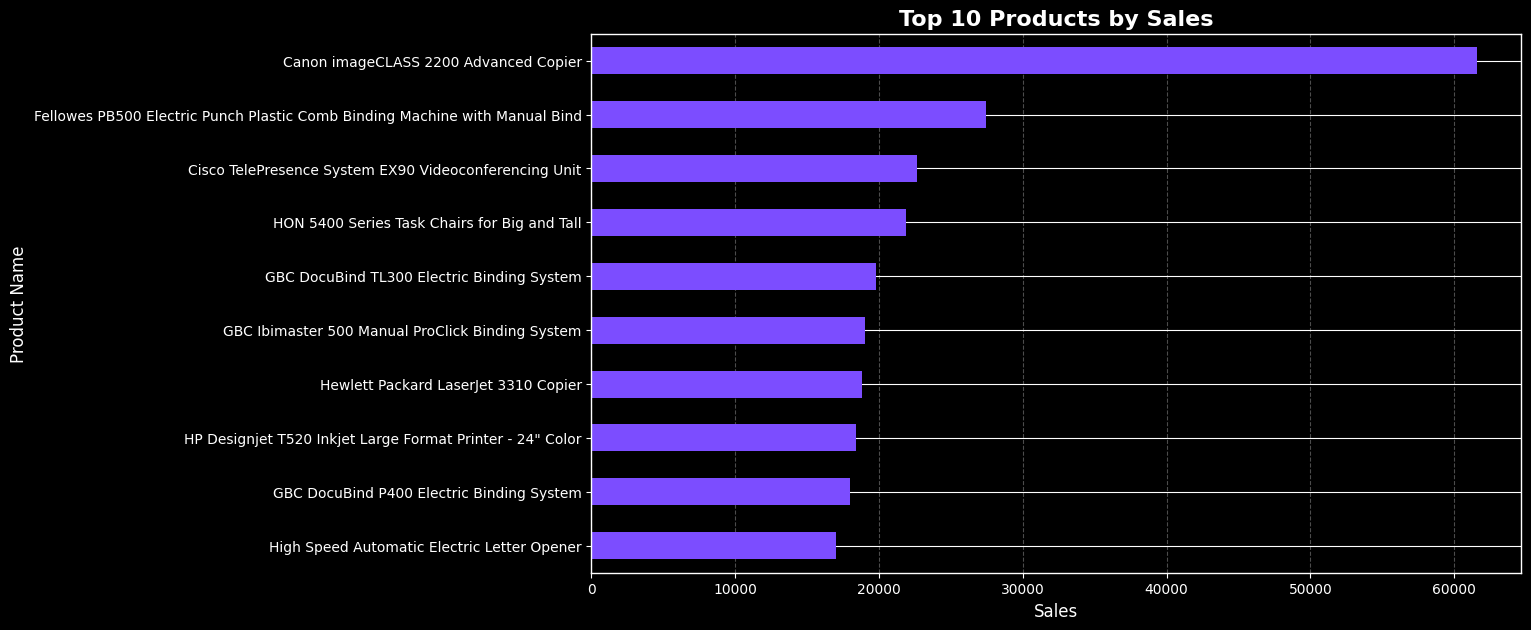

In [16]:
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,7))

top_products.sort_values().plot(
    kind='barh',
    color='#7C4DFF'
)

plt.title('Top 10 Products by Sales', fontsize=16, fontweight='bold')
plt.xlabel('Sales')
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

## Sales vs Profit Relationship Analysis

This scatter plot examines the relationship between sales and profit.

### Objective
To understand whether higher sales result in higher profits.

### Observation
A positive relationship exists between sales and profit, although some high-sales transactions generate relatively low profits.

### Insight
High revenue does not always guarantee high profitability, emphasizing the importance of pricing and discount strategies.

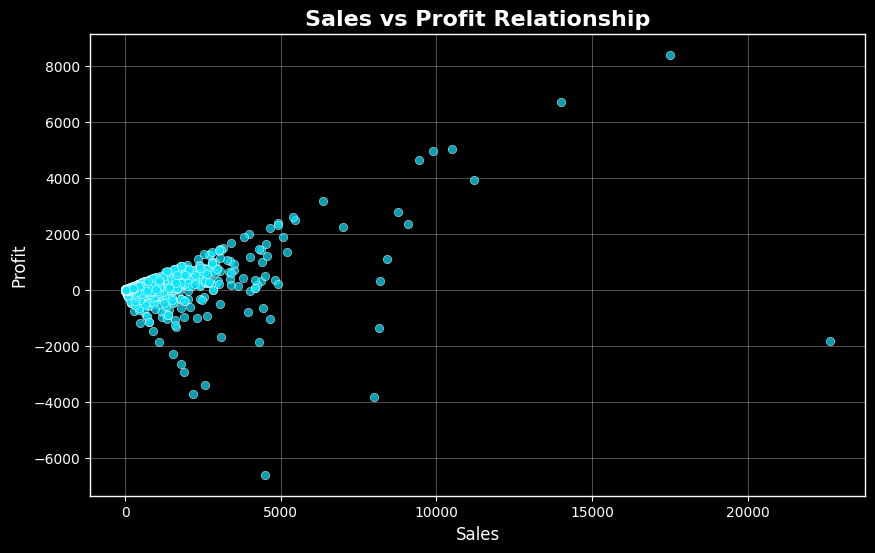

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    color='#00E5FF',
    alpha=0.7
)

plt.title('Sales vs Profit Relationship', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.show()

## Correlation Analysis

This heatmap visualizes the relationships between key numerical variables in the dataset.

### Objective
To understand how different business metrics influence each other.

### Observation
Sales and Profit show a moderate positive correlation, while Discount has a negative correlation with Profit.

### Insight
Increasing discounts may reduce profitability, making discount management an important factor in business performance.

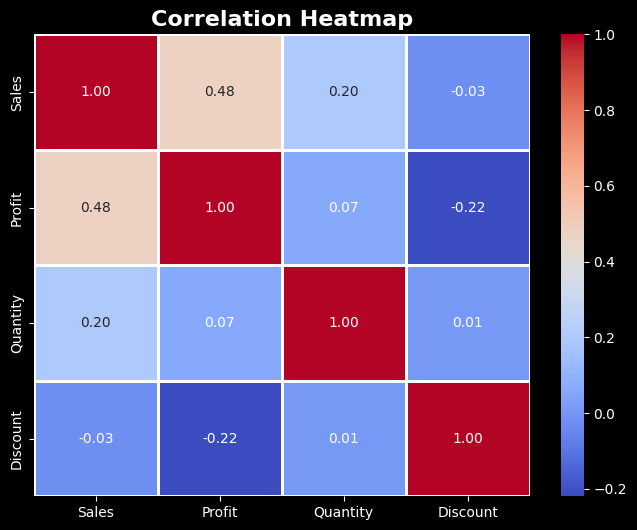

In [18]:
corr = df[['Sales','Profit','Quantity','Discount']].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=1,
    fmt='.2f'
)

plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')

plt.show()

## Top 5 Loss-Making Products Analysis

This visualization identifies products that generated the highest losses for the company.

### Objective
To determine which products negatively impact overall profitability.

### Observation
Certain products consistently generate negative profit despite being sold frequently.

### Insight
These products should be reviewed for pricing strategies, discount policies, supplier costs, or operational inefficiencies.

### Business Recommendation
Management should investigate loss-making products and consider adjusting pricing, reducing discounts, or discontinuing underperforming items.

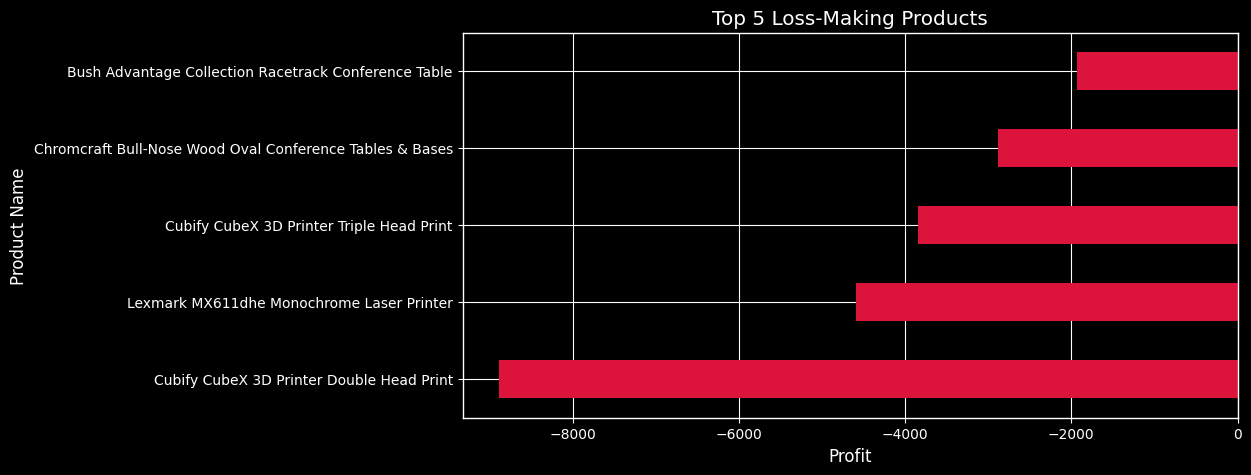

In [19]:
loss_products = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values()
    .head(5)
)

plt.figure(figsize=(10,5))
loss_products.plot(kind='barh', color='crimson')

plt.title('Top 5 Loss-Making Products')
plt.xlabel('Profit')
plt.show()

## Sales Distribution Analysis

This histogram visualizes the distribution of sales transactions across the dataset.

### Objective
To understand how sales values are distributed and identify common transaction sizes.

### Observation
Most sales transactions fall within a lower sales range, while a small number of transactions contribute exceptionally high sales values.

### Insight
The dataset contains a large number of small-to-medium sales transactions and a few high-value transactions, indicating a positively skewed distribution.

### Business Recommendation
The company should focus on both increasing the frequency of smaller sales and maintaining high-value customer transactions.

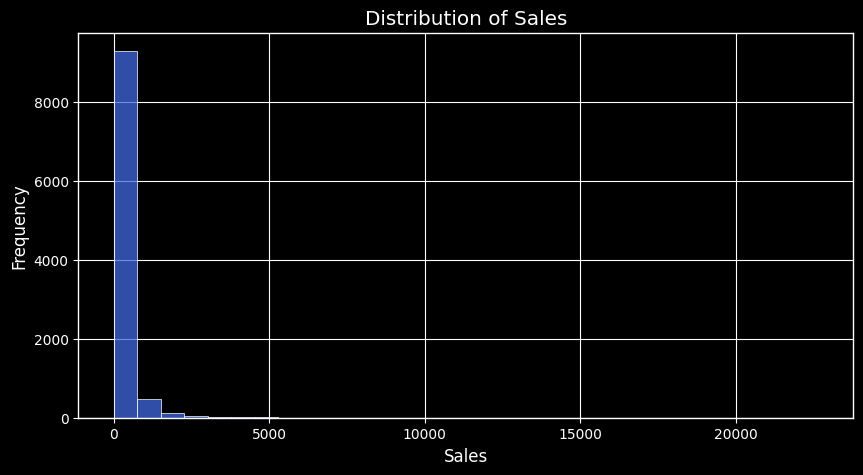

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(df['Sales'], bins=30, color='royalblue')

plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

## Business Impact

The insights obtained from this analysis can support data-driven decision-making across multiple business functions.

### Key Benefits

- Identified the highest-performing product categories.
- Highlighted profitable and underperforming regions.
- Revealed seasonal sales patterns.
- Measured the impact of discounts on profitability.
- Identified products contributing to financial losses.

### Strategic Value

These findings can help management improve inventory planning, optimize pricing strategies, increase profitability, and allocate resources more effectively.

# Conclusion

The Superstore dataset was analyzed using Exploratory Data Analysis (EDA) techniques to identify sales patterns, profitability trends, and business opportunities.

## Key Findings

1. Technology generated the highest sales and profit among all categories.
2. Furniture recorded strong sales but comparatively low profit.
3. The West region was the best-performing region in both sales and profit.
4. Sales peaked during November and December, indicating seasonal demand.
5. Discounts negatively affected profitability.
6. A moderate positive relationship was observed between sales and profit.

## Recommendations

- Increase focus on Technology products.
- Optimize pricing and discount strategies.
- Improve profitability in the Furniture category.
- Prepare additional inventory for peak sales months.
- Apply successful strategies from the West region to other regions.

## Outcome

The analysis successfully identified important business trends and provided actionable recommendations for improving sales performance and profitability.

## Thank You

This project demonstrates the practical application of Exploratory Data Analysis techniques for transforming raw business data into meaningful insights and supporting data-driven decision-making.